In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm
from blackjack import BlackjackEnv
import seaborn as sns
import sys
from itertools import product
import random


env=BlackjackEnv(natural=False,sab=True)
combinations = list(product(range(12,22), range(1,11), [0,1], [0,1]))
all_states = list(product(range(12,22), range(1,11), [0,1]))


#behaviour policy equal probability to each action
def behaviour_policy(pi,observation):   
    if np.random.binomial(1, 0.5) == 1:
        return 0
    return 1

#target policy
def target_policy(pi,observation):
    return pi[observation]


#generate an episode using a policy
def blackjack_episode(policy_func,pi,player_sum=None,dealer_card=None,usable_ace=None,initial_action=None):
    # Reset the environment to generate the first observation
    states=[]
    actions=[]
    rewards=[0]
    if player_sum==None:
        while(True):
            observation, info = env.reset()
            if(observation[0]<12):
                continue
            else:
                break
    #if starting state is given
    else:
        observation,info=env.start_state(player_sum=player_sum,dealer_card=dealer_card,usable_ace=usable_ace)
    states.append(observation)  
    while(True):
        #if starting action is given
        if initial_action!=None:
            action=initial_action
            initial_action=None
        else:
            action=policy_func(pi,tuple(np.array(observation)-(12,1,0)))
        
        actions.append(action)
        observation, reward, terminated, truncated, info = env.step(action)
        rewards.append(reward)
        states.append(observation)

        if terminated or truncated:
            states.pop(len(states)-1)
            break

    return states, actions, rewards





env.close()

## Fig 5.1

100%|██████████| 490000/490000 [01:06<00:00, 7385.92it/s]


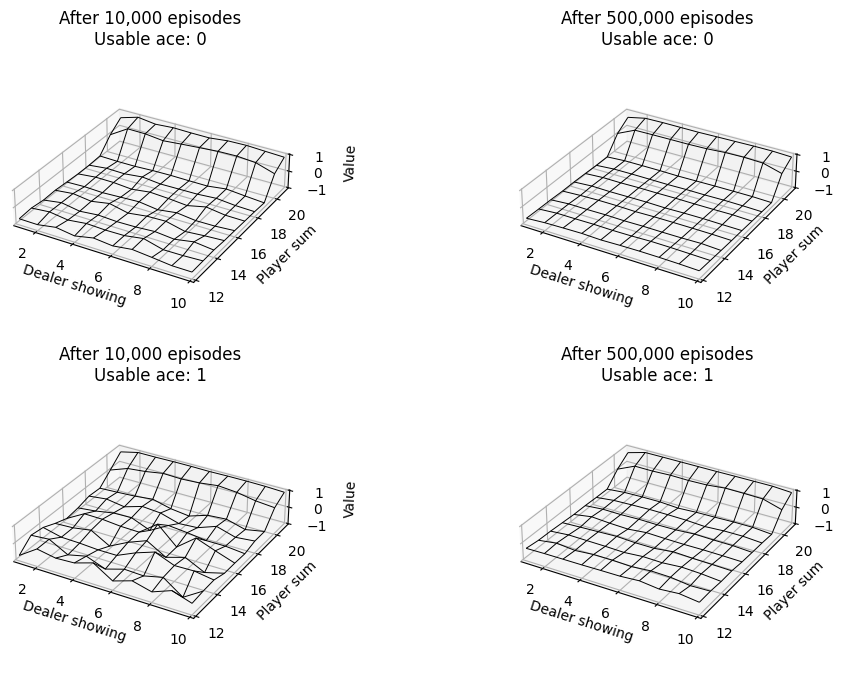

In [2]:


def first_visit_mc(num_episodes,v_values=None,v_counts=None):
    pi=np.ones((10,10,2),dtype=int)
    pi[9,:,:]=0
    pi[8,:,:]=0
    
    if v_values.all()==None:
        v_values=np.zeros((10,10,2))
        v_counts=np.zeros((10,10,2))   
    for j in tqdm(range(num_episodes)):
        states, actions, rewards = blackjack_episode(target_policy,pi)#generate episode
        #update values for each state in episode
        gt=0
        for i in range(len(states)-1,-1,-1):
            gt=rewards[i+1]+gt
            state=states[i]

            if states[i] not in states[0:i]:
                state=(state[0]-12,state[1]-1,state[2])
                v_counts[state]=v_counts[state]+1
                v_values[state]=v_values[state]+(gt-v_values[state])/(v_counts[state])

    return v_values,v_counts

#display the results of first-visit monte carlo
def display_first_visit(num_episodes,values,v_counts=None):
    x_all,y_all,z_all=[],[],[]  
    v_values,v_counts=first_visit_mc(num_episodes,values,v_counts) 
    for i in range(2):
        dealer_showing=[]
        player_sum=[]
        values=[]
        for j in range(10):
            for k in range(10):
                values.append(v_values[j,k,i])
                player_sum.append(j+12)
                dealer_showing.append(k+1)
                
        #create 3d grid
        x=np.array(player_sum)
        y=np.array(dealer_showing)
        z=np.array(values)
        dealer_card = range(1,11)
        curr_sum=range(12,22)
        x_grid, y_grid = np.meshgrid(dealer_card, curr_sum)

        z_grid = np.zeros_like(x_grid).astype('float')
        for cs,dc,v in zip(x,y,z):
            z_grid[cs-12,dc-1]=v
        x_all.append(x_grid)    
        y_all.append(y_grid)
        z_all.append(z_grid)
    return x_all,y_all,z_all,v_values,v_counts

def fig_5_1():
    fig = plt.figure(figsize=(12, 8))
    x_all,y_all,z_all,v_values,v_counts=display_first_visit(10000,np.array([None]))
    t=0
    for i in range(len(x_all)):
        ax1 = fig.add_subplot(221+t, projection='3d')
        ax1.plot_wireframe(x_all[i], y_all[i], z_all[i], linewidth=0.7, color='k')
        ax1.set_zlim(-1, 1)
        ax1.set_xlim(1, 10)
        ax1.set_ylim(12, 21)
        ax1.set_zticks([-1, 0, 1])
        ax1.set_box_aspect([1,1,0.2])
        ax1.set_title('After 10,000 episodes\nUsable ace: '+str(i))
        ax1.set_xlabel('Dealer showing')
        ax1.set_ylabel('Player sum')
        ax1.set_zlabel('Value')
        t+=2

    t=1
    x_all,y_all,z_all,_,_=display_first_visit(490000,v_values,v_counts)
    for i in range(len(x_all)):
        ax1 = fig.add_subplot(221+t, projection='3d')
        ax1.plot_wireframe(x_all[i], y_all[i], z_all[i], linewidth=0.7, color='k')
        ax1.set_zlim(-1, 1)
        ax1.set_xlim(1, 10)
        ax1.set_ylim(12, 21)
        ax1.set_zticks([-1, 0, 1])
        ax1.set_box_aspect([1,1,0.2])
        ax1.set_title('After 500,000 episodes\nUsable ace: '+str(i))
        ax1.set_xlabel('Dealer showing')
        ax1.set_ylabel('Player sum')
        ax1.set_zlabel('Value')
        t+=2
    plt.show()

fig_5_1()

## Fig 5.2

100%|██████████| 500000/500000 [00:40<00:00, 12336.72it/s]


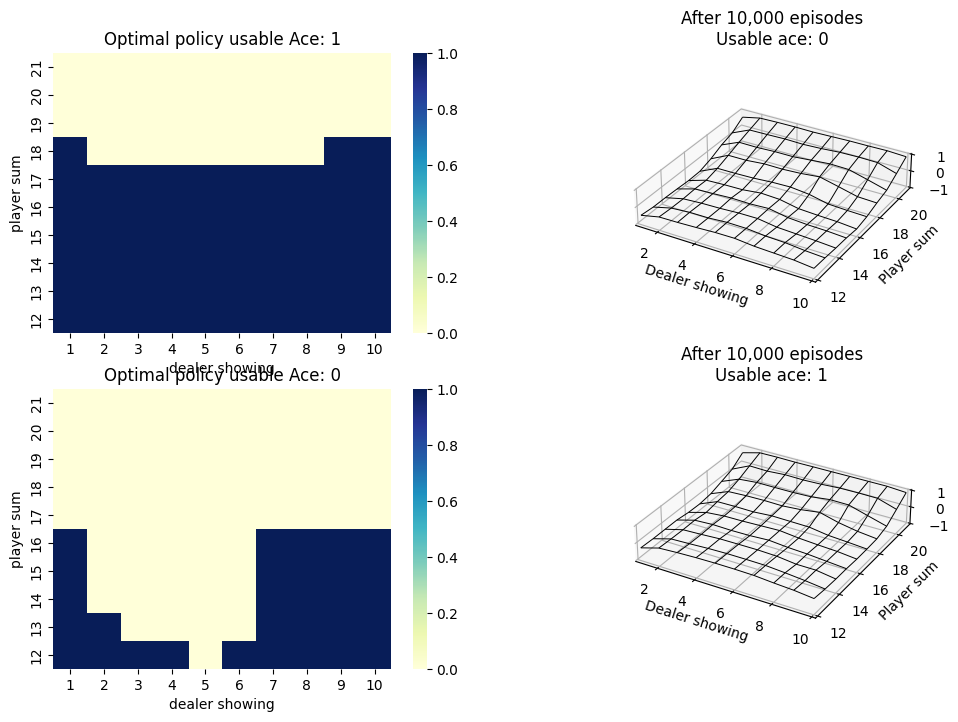

In [3]:
def es_mc(num_episodes):
    #target policy
    pi=np.ones((10,10,2),dtype=int)
    pi[9,:,:]=0
    pi[8,:,:]=0

    q_values=np.zeros((10,10,2,2))#state-action values
    q_counts=np.zeros((10,10,2,2))#number of times each state-action pair is visited
                 
    for j in tqdm(range(num_episodes)):
        
        # player_sum,dealer_card,usable_ace,action=(np.random.choice(range(12,22)),np.random.choice(range(1,11)),np.random.choice([0,1]),np.random.choice([0,1]))#exploring starts
        player_sum,dealer_card,usable_ace,action=random.choice(combinations)#choose a starting state and action with equal probability
        states, actions, rewards = blackjack_episode(target_policy,pi,player_sum,dealer_card,usable_ace,action)#generate episode with given starting state
        history=[i[0]+tuple([i[1]]) for i in zip(states,actions)]#the history of states and actions

        #update values of each state in episode
        gt=0
        for i in range(len(states)-1,-1,-1):
            gt=rewards[i+1]+gt
            state=states[i]
            action=actions[i]
            pair=state+tuple([action])#state-action pair
            if pair not in history[0:i]:
                state=(state[0]-12,state[1]-1,state[2])
                pair=state+tuple([action])
                q_counts[pair]+=1
                q_values[pair]+=(gt-q_values[pair])/(q_counts[pair])
                pi[state]=np.argmax([q_values[state+(0,)],q_values[state+(1,)]])#update policy
    return q_values


#display the results of es-monte carlo
def display_es(num_episodes):
    q_values=es_mc(num_episodes)
    x_all,y_all,z_all=[],[],[]   
    for i in range(2):
        dealer_showing=[]
        player_sum=[]
        values=[]
        for k in all_states:
            j=k
            if j[2]==i:
                values.append(np.max([q_values[(j[0]-12,j[1]-1,j[2])+(0,)],q_values[(j[0]-12,j[1]-1,j[2])+(1,)]]))
                player_sum.append(j[0])
                dealer_showing.append(j[1])

        #create 3d grid    
        x=np.array(player_sum)
        y=np.array(dealer_showing)
        z=np.array(values)
        dealer_card = range(1,11)
        curr_sum=range(12,22)
        x_grid, y_grid = np.meshgrid(dealer_card, curr_sum)
        z_grid = np.zeros_like(x_grid).astype('float')
        for cs,dc,v in zip(x,y,z):
            z_grid[cs-12,dc-1]=v
        x_all.append(x_grid)    
        y_all.append(y_grid)
        z_all.append(z_grid)

    return x_all,y_all,z_all,q_values

def fig_5_2():
    x_all,y_all,z_all,q_values=display_es(500000)

    action_no_usable_ace = np.argmax(q_values[:, :, 0, :], axis=-1)
    action_usable_ace = np.argmax(q_values[:, :, 1, :], axis=-1)

    images = [action_usable_ace,
              action_no_usable_ace]
    
    titles = ['Optimal policy usable Ace: 1','Optimal policy usable Ace: 0',]

    fig = plt.figure(figsize=(12, 8))
    
    t=0
    for image, title in zip(images, titles):
        ax1=fig.add_subplot(221+t)
        ax1 = sns.heatmap(np.flipud(image), cmap="YlGnBu", ax=ax1, xticklabels=range(1, 11),
                          yticklabels=list(reversed(range(12, 22))))
        ax1.set_ylabel('player sum')
        ax1.set_xlabel('dealer showing')
        ax1.set_title(title)
        t+=2

    t=1
    for i in range(len(x_all)):
        ax1 = fig.add_subplot(221+t, projection='3d')
        ax1.plot_wireframe(x_all[i], y_all[i], z_all[i], linewidth=0.7, color='k')
        ax1.set_zlim(-1, 1)
        ax1.set_xlim(1, 10)
        ax1.set_ylim(12, 21)
        ax1.set_zticks([-1, 0, 1])
        ax1.set_box_aspect([1,1,0.2])
        ax1.set_title('After 10,000 episodes\nUsable ace: '+str(i))
        ax1.set_xlabel('Dealer showing')
        ax1.set_ylabel('Player sum')
        ax1.set_zlabel('Value')
        t+=2
    plt.show()
    
fig_5_2()

## Fig 5.3

In [ ]:

#importance sampling
def imp_sampling(num_episodes,v_values):
    #target policy
    pi=np.ones((10,10,2),dtype=int)
    pi[9,:,:]=0
    pi[8,:,:]=0

    ordinary_gt=[]#ordinary importance sampling
    weighted_gt=[]#weighted importance sampling
    ordinary_s=0#accumulation of returns
    samplings=0#accumulation of importance sampling ratio

    for j in range(num_episodes):
        player_sum,dealer_card,usable_ace,action=(13,2,1,np.random.choice([0,1]))#intial state and action fixed
        states, actions, rewards = blackjack_episode(behaviour_policy,pi,player_sum,dealer_card,usable_ace,action)#generate episode with fixed starting state and action    
        gt=0
        #calculate importance sampling ratio
        sampling_factor=1
        for i in range(len(states)-1,-1,-1):
            if actions[i]!=target_policy(pi,(states[i][0]-12,states[i][1]-1,states[i][2])):
                sampling_factor=0
            else:
                sampling_factor=2*sampling_factor
            gt=rewards[i+1]+gt

        samplings+=sampling_factor
        ordinary_s+=sampling_factor*gt
        ordinary_gt.append(ordinary_s/(j+1))#ordinary importance sampling
        #weighted importance sampling
        if samplings==0:
            weighted_gt.append(0)
        else:
            weighted_gt.append(ordinary_s/samplings)
    
    return ordinary_gt,weighted_gt

def fig_5_3():
    true_values=-0.27726
    num_runs=100
    num_episodes=10000
    error_ordinary = np.zeros(num_episodes)
    error_weighted = np.zeros(num_episodes)
    for i in tqdm(range(num_runs)):
        estimated,weighted_estimate=imp_sampling(num_episodes,None)
        error_ordinary+=np.square(np.array(estimated)-true_values)
        error_weighted+=np.square(np.array(weighted_estimate)-true_values)
    error_ordinary /= num_runs
    print(error_ordinary)
    error_weighted /= num_runs

    plt.plot(error_ordinary, label='Ordinary Importance Sampling')
    plt.plot(error_weighted, label='Weighted Importance Sampling')
    plt.xlabel('Episodes (log scale)')
    plt.ylabel('Mean square error')
    plt.xscale('log')
    plt.legend()

    plt.show()
    plt.close()

fig_5_3()

 97%|█████████▋| 97/100 [01:32<00:02,  1.03it/s]